# IRB capital requirement as a function of PD

This notebook visualises the Basel IRB capital requirement as a function of the estimated probability of default, $\widehat{PD}$. The aim is to make the non-linearity of $K_{\mathrm{IRB}}(\widehat{PD})$ visible and to provide a compact implementation check for the regulatory formula.

First compute the asset correlation as a function of $\widehat{PD}$:

$$
R(\widehat{PD}) = 0.12 \cdot \frac{1 - e^{-50\widehat{PD}}}{1 - e^{-50}}
                  + 0.24 \cdot \left(1 - \frac{1 - e^{-50\widehat{PD}}}{1 - e^{-50}}\right).
$$

The IRB capital requirement is then

$$
K_{\mathrm{IRB}}(\widehat{PD}) = LGD \cdot \left[
    N\!\left(
            \frac{G(\widehat{PD})}{\sqrt{1-R(\widehat{PD})}}
            + \sqrt{\frac{R(\widehat{PD})}{1-R(\widehat{PD})}} \cdot G(0.999)
        \right)- \widehat{PD} \right],
$$

where $N$ is the standard normal CDF and $G$ is the inverse standard normal CDF.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
def asset_correlation(pd_hat):
    """Basel corporate IRB asset correlation R(PD)."""
    pd_hat = np.asarray(pd_hat, dtype=float)
    exponential_weight = (1 - np.exp(-50 * pd_hat)) / (1 - np.exp(-50))
    return 0.12 * exponential_weight + 0.24 * (1 - exponential_weight)


def k_irb(pd_hat, lgd=0.45):
    """IRB capital requirement K_IRB(PD) for a given LGD."""
    pd_hat = np.asarray(pd_hat, dtype=float)
    r = asset_correlation(pd_hat)
    systematic_shock = norm.ppf(0.999)
    conditional_default_argument = (
        norm.ppf(pd_hat) / np.sqrt(1 - r)
        + np.sqrt(r / (1 - r)) * systematic_shock
    )
    b = (0.11852 -0.05478*np.log(pd_hat))**2
    maturity_adjustment = 1/(1-1.5*b)
    return (lgd * norm.cdf(conditional_default_argument) - pd_hat *lgd )*maturity_adjustment
    

Use a dense grid of PD values from 0.01% to 20%. The lower bound avoids evaluating $G(0)$, which is undefined.

In [3]:
lgd = 0.45
pd_grid = np.linspace(0.0001, 0.20, 2_000)
r_grid = asset_correlation(pd_grid)
k_grid = k_irb(pd_grid, lgd=lgd)

check_points = np.array([0.0001, 0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20])
checkpoint_table = pd.DataFrame({
    "PD": check_points,
    "PD (%)": 100 * check_points,
    "R(PD)": asset_correlation(check_points),
    "K_IRB": k_irb(check_points, lgd=lgd),
    "K_IRB (%)": 100 * k_irb(check_points, lgd=lgd),
})

checkpoint_table.round({
    "PD": 4,
    "PD (%)": 2,
    "R(PD)": 4,
    "K_IRB": 4,
    "K_IRB (%)": 2,
})

,PD,PD (%),R(PD),K_IRB,K_IRB (%)
0,0.0001,0.01,0.2394,0.0060,0.60
1,0.0010,0.10,0.2341,0.0237,2.37
2,0.0050,0.50,0.2135,0.0557,5.57
3,0.0100,1.00,0.1928,0.0739,7.39
4,0.0200,2.00,0.1641,0.0919,9.19
5,0.0500,5.00,0.1299,0.1199,11.99
6,0.1000,10.00,0.1208,0.1545,15.45
7,0.2000,20.00,0.1200,0.1906,19.06


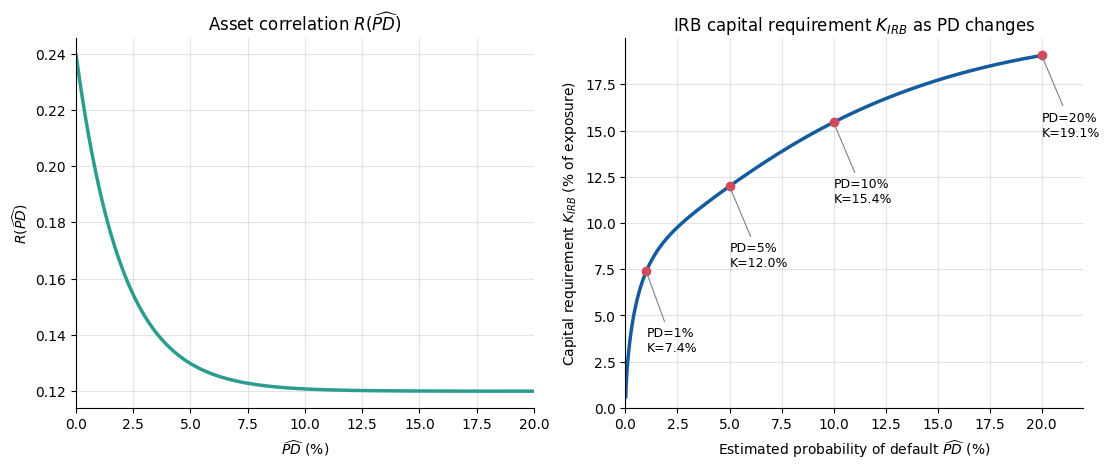

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(100 * pd_grid, r_grid, color="#2a9d8f", linewidth=2.5)
axes[0].set_title(r"Asset correlation $R(\widehat{PD})$")
axes[0].set_xlabel(r"$\widehat{PD}$ (%)")
axes[0].set_ylabel(r"$R(\widehat{PD})$")
axes[0].set_xlim(0, 20)

axes[1].plot(100 * pd_grid, 100 * k_grid, color="#145c9e", linewidth=2.5)
axes[1].set_title(r"IRB capital requirement $K_{IRB}$ as PD changes")
axes[1].set_xlabel(r"Estimated probability of default $\widehat{PD}$ (%)")
axes[1].set_ylabel(r"Capital requirement $K_{IRB}$ (% of exposure)")
axes[1].set_xlim(0, 22)  # Extended beyond 20 so the last label isn't cut off
axes[1].set_ylim(bottom=0)

for pd_point in [0.01, 0.05, 0.10, 0.20]:
    k_point = k_irb(pd_point, lgd=lgd)
    axes[1].scatter(100 * pd_point, 100 * k_point, color="#d1495b", zorder=3)
    axes[1].annotate(
        f"PD={100 * pd_point:.0f}%\nK={100 * k_point:.1f}%",
        xy=(100 * pd_point, 100 * k_point),
        xytext=(0, -40),          # Shift straight down
        textcoords="offset points",
        fontsize=9,
        ha="left",              # Centre-align under the dot
        va="top",
        arrowprops=dict(
            arrowstyle="-",       # Plain line, no arrowhead
            color="gray",
            lw=0.8,
        ),
    )
plt.savefig('figures/IRB_capital_non_linear.png')
plt.show()

The asset correlation decreases with PD under this formula, while the conditional default quantile term still makes the final capital curve strongly non-linear.

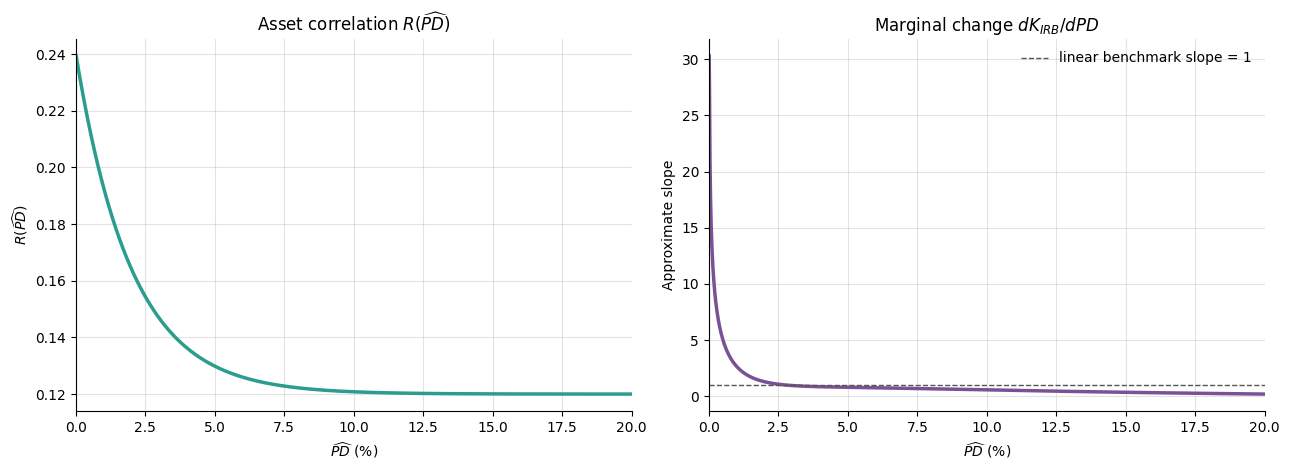

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(100 * pd_grid, r_grid, color="#2a9d8f", linewidth=2.5)
axes[0].set_title(r"Asset correlation $R(\widehat{PD})$")
axes[0].set_xlabel(r"$\widehat{PD}$ (%)")
axes[0].set_ylabel(r"$R(\widehat{PD})$")
axes[0].set_xlim(0, 20)

capital_slope = np.gradient(k_grid, pd_grid)
axes[1].plot(100 * pd_grid, capital_slope, color="#7a5195", linewidth=2.5)
axes[1].axhline(1, color="#555555", linewidth=1, linestyle="--", label="linear benchmark slope = 1")
axes[1].set_title(r"Marginal change $dK_{IRB}/dPD$")
axes[1].set_xlabel(r"$\widehat{PD}$ (%)")
axes[1].set_ylabel(r"Approximate slope")
axes[1].set_xlim(0, 20)
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

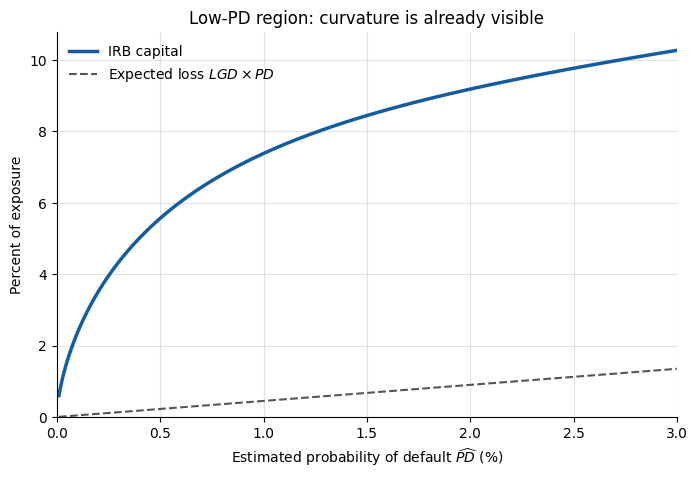

In [6]:
fig, ax = plt.subplots()

pd_zoom = np.linspace(0.0001, 0.03, 1_500)
ax.plot(100 * pd_zoom, 100 * k_irb(pd_zoom, lgd=lgd), color="#145c9e", linewidth=2.5, label="IRB capital")
ax.plot(100 * pd_zoom, 100 * lgd * pd_zoom, color="#555555", linestyle="--", linewidth=1.5, label=r"Expected loss $LGD \times PD$")

ax.set_title("Low-PD region: curvature is already visible")
ax.set_xlabel(r"Estimated probability of default $\widehat{PD}$ (%)")
ax.set_ylabel("Percent of exposure")
ax.set_xlim(0, 3)
ax.set_ylim(bottom=0)
ax.legend(frameon=False)

plt.show()